## Análisis Exploratorio de Datos (EDA)

### Objetivo
Este notebook realiza un **análisis exploratorio** sobre los datasets extraídos del INE para verificar la integridad, calidad y estructura de los datos antes de las transformaciones.

Se examinan los siete DataFrames generados en la fase de extracción:
- **Empresas constituidas** (`empresas_constituidas.csv`) — Verificación de tipos societarios, consistencia de capital y nº de sociedades.
- **Empresas disueltas** (`empresas_disueltas.csv`) — Distribución por causa de disolución y territorio.
- **IPC** (`ipc.csv`) — Rango de valores, detección de outliers y cardinalidad de dimensiones.
- **Tablas dimensionales** (`sectores_ipc`, `territorio`, `tiempo`, `tipo_medida`) — Validación de claves y completitud.

### Metodología
1. **Carga** de los CSV desde `../files/data_raw/`.
2. **Inspección** mediante `info()`, `describe()`, `sample()` y `value_counts()`.
3. **Detección de inconsistencias** — Identificación de filas duplicadas (como los agregados "Mercantiles" que sumarizan a S.A. y S.L.) y valores anómalos.
4. **Documentación de hallazgos** — Conclusiones que guiarán las transformaciones en la siguiente etapa del pipeline.

In [2]:
# Importación de librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Configuración de el estilo de los graficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
# Configuración para visualizar todas las columnas
pd.set_option('display.max_columns', None)

1. Revisamos los archivos exportados para comprobar la integridad de los datos

In [3]:
df_empr_const = pd.read_csv('../files/data_raw/empresas_constituidas.csv', index_col=0)

In [4]:
df_empr_const.sample(5)

,territorio,id_tiempo,tipo,numero_sociedades,capital
id_const,,,,,
9684,Castilla y León,202601,Sociedades de responsabilidad limitada,304,6858000
11517,"Navarra, Comunidad Foral de",201912,Sociedades de responsabilidad limitada,45,4438000
14709,Comunitat Valenciana,201008,S. Comanditarias y S. Colectivas,0,0
11061,"Madrid, Comunidad de",202104,Sociedades de responsabilidad limitada,2310,56930000
3705,"Rioja, La",201012,Mercantiles,29,356000


In [5]:
df_empr_const.info()

<class 'pandas.DataFrame'>
RangeIndex: 16720 entries, 1 to 16720
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   territorio         16720 non-null  str  
 1   id_tiempo          16720 non-null  int64
 2   tipo               16720 non-null  str  
 3   numero_sociedades  16720 non-null  int64
 4   capital            16720 non-null  int64
dtypes: int64(3), str(2)
memory usage: 653.3 KB


In [6]:
df_empr_const.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
id_tiempo,16720.0,2.016737e+05,5.294115e+02,200801.0,201207.75,201702.5,202109.25,2.026040e+05
numero_sociedades,16720.0,2.134034e+02,4.471220e+02,0.0,0.00,7.0,215.00,3.173000e+03
capital,16720.0,1.544442e+07,1.489657e+08,0.0,0.00,442000.0,7895000.00,1.259172e+10


In [7]:
df_empr_const.describe(include='string').T

,count,unique,top,freq
territorio,16720,19,Andalucía,880
tipo,16720,4,Mercantiles,4180


In [8]:
df_empr_const["territorio"].unique()

<StringArray>
[                  'Andalucía',                      'Aragón',
     'Asturias, Principado de',              'Balears, Illes',
                    'Canarias',                   'Cantabria',
             'Castilla y León',        'Castilla - La Mancha',
                    'Cataluña',        'Comunitat Valenciana',
                 'Extremadura',                     'Galicia',
        'Madrid, Comunidad de',           'Murcia, Región de',
 'Navarra, Comunidad Foral de',                  'País Vasco',
                   'Rioja, La',                       'Ceuta',
                     'Melilla']
Length: 19, dtype: str

Pendiente de arreglar los nombres, minúsculas, tildes, etc. normalizar la columna

In [9]:
df_empr_const["tipo"].unique()

<StringArray>
[                           'Mercantiles',
                    'Sociedades anónimas',
 'Sociedades de responsabilidad limitada',
       'S. Comanditarias y S. Colectivas']
Length: 4, dtype: str

Tras revisar los tipos de empresa, nos damos cuenta que "Mercantiles" es un total de las empresas SL, y SA, vamos a comprobarlo.

In [10]:
df_empr_const[df_empr_const["tipo"] == "Mercantiles"].sample(10)

,territorio,id_tiempo,tipo,numero_sociedades,capital
id_const,,,,,
4011,Melilla,202202,Mercantiles,9,29000
2952,"Murcia, Región de",201809,Mercantiles,199,3870000
1145,Cantabria,202208,Mercantiles,54,1064000
2221,Extremadura,202408,Mercantiles,89,2955000
1088,Canarias,200901,Mercantiles,250,3798000
3053,"Murcia, Región de",201004,Mercantiles,226,6546000
2534,Galicia,201611,Mercantiles,365,20909000
2086,Comunitat Valenciana,201707,Mercantiles,936,105387000
1938,Cataluña,201107,Mercantiles,1173,118931000


In [11]:
df_empr_const["tipo"].value_counts()

tipo
Mercantiles                               4180
Sociedades anónimas                       4180
Sociedades de responsabilidad limitada    4180
S. Comanditarias y S. Colectivas          4180
Name: count, dtype: int64

La razón que los valores totales coinciden es porque hay una fila por fecha, independientemente si hay disueltas o no (0)

In [12]:
df_empr_const[df_empr_const["tipo"] == "Mercantiles"].shape

(4180, 5)

In [13]:
df_empr_const[(df_empr_const["territorio"] == "Melilla") & (df_empr_const["id_tiempo"] == 202505)].head(100)

,territorio,id_tiempo,tipo,numero_sociedades,capital
id_const,,,,,
3972,Melilla,202505,Mercantiles,10,1037000
8152,Melilla,202505,Sociedades anónimas,0,0
12332,Melilla,202505,Sociedades de responsabilidad limitada,10,1037000
16512,Melilla,202505,S. Comanditarias y S. Colectivas,0,0


In [14]:
df_empr_const[(df_empr_const["territorio"] == "Canarias") & (df_empr_const["id_tiempo"] == 202006)].head(100)

,territorio,id_tiempo,tipo,numero_sociedades,capital
id_const,,,,,
951,Canarias,202006,Mercantiles,186,155088000
5131,Canarias,202006,Sociedades anónimas,0,0
9311,Canarias,202006,Sociedades de responsabilidad limitada,186,155088000
13491,Canarias,202006,S. Comanditarias y S. Colectivas,0,0


In [15]:
df_empr_const[(df_empr_const["territorio"] == "Andalucía") & (df_empr_const["id_tiempo"] == 202407)].head(100)

,territorio,id_tiempo,tipo,numero_sociedades,capital
id_const,,,,,
22,Andalucía,202407,Mercantiles,1564,78298000
4202,Andalucía,202407,Sociedades anónimas,2,1840000
8382,Andalucía,202407,Sociedades de responsabilidad limitada,1562,76458000
12562,Andalucía,202407,S. Comanditarias y S. Colectivas,0,0


In [16]:
df_empr_const.columns

Index(['territorio', 'id_tiempo', 'tipo', 'numero_sociedades', 'capital'], dtype='str')

In [17]:
df_empr_const.duplicated().sum()

0

Confirmamos nuestras sospechas, procederemos en el paso de transformación a eliminar esas filas. df_empr_const["tipo"] == "Mercantiles"

------------------------------------

In [18]:
df_empr_dis = pd.read_csv('../files/data_raw/empresas_disueltas.csv', index_col=0)

In [19]:
df_empr_dis.sample(5)

,territorio,id_tiempo,razon,numero_sociedades
id_dis,,,,
8389,Andalucía,202312,Otras,30
7742,"Rioja, La",202211,Por fusión,1
11706,País Vasco,202207,Otras,7
8234,Melilla,201807,Por fusión,0
3828,Ceuta,201901,Voluntaria,6


In [20]:
df_empr_dis.info()

<class 'pandas.DataFrame'>
RangeIndex: 12540 entries, 1 to 12540
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   territorio         12540 non-null  str  
 1   id_tiempo          12540 non-null  int64
 2   razon              12540 non-null  str  
 3   numero_sociedades  12540 non-null  int64
dtypes: int64(2), str(2)
memory usage: 392.0 KB


In [21]:
df_empr_dis.shape

(12540, 4)

In [22]:
df_empr_dis.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
id_tiempo,12540.0,201673.700000,529.416812,200801.0,201207.75,201702.5,202109.25,202604.0
numero_sociedades,12540.0,32.513238,71.914047,0.0,2.00,8.0,31.00,1114.0


In [23]:
df_empr_dis.describe(include='string').T

,count,unique,top,freq
territorio,12540,19,Andalucía,660
razon,12540,3,Voluntaria,4180


In [24]:
df_empr_dis["razon"].value_counts()

razon
Voluntaria    4180
Por fusión    4180
Otras         4180
Name: count, dtype: int64

In [25]:
df_empr_dis.duplicated().sum()

0

La razón que los valores totales coinciden es porque hay una fila por fecha, independientemente si hay disueltas o no (0)

-------------------------

In [26]:
df_ipc = pd.read_csv('../files/data_raw/ipc.csv')

In [27]:
df_ipc.sample(10)

,id_tiempo,id_territorio,id_sector,id_medida,valor_ipc
175067,201405,11,10,2,-1.200
107235,200205,7,8,2,0.200
71799,202505,5,6,2,0.500
172266,200308,11,7,4,2.200
26883,200803,2,9,4,-0.700
299788,202206,19,4,4,4.400
229897,201102,15,1,1,76.235
69038,201104,5,3,4,2.300
149887,201211,10,2,4,2.600
89836,201109,6,7,3,-1.900


In [28]:
df_ipc.info()

<class 'pandas.DataFrame'>
RangeIndex: 328162 entries, 0 to 328161
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   id_tiempo      328162 non-null  int64  
 1   id_territorio  328162 non-null  int64  
 2   id_sector      328162 non-null  int64  
 3   id_medida      328162 non-null  int64  
 4   valor_ipc      328162 non-null  float64
dtypes: float64(1), int64(4)
memory usage: 12.5 MB


In [29]:
df_ipc.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
id_tiempo,328162.0,201377.778817,705.032930,200201.0,200802.0,201403.0,202004.0000,202606.000
id_territorio,328162.0,10.499942,5.766320,1.0,5.0,10.0,15.0000,20.000
id_sector,328162.0,7.499960,4.031155,1.0,4.0,7.0,11.0000,14.000
id_medida,328162.0,2.500000,1.118033,1.0,2.0,2.5,3.0000,4.000
valor_ipc,328162.0,21.500742,37.058520,-22.4,0.1,1.5,37.3585,258.216


In [30]:
df_ipc[df_ipc["valor_ipc"] == -22.4].head()

,id_tiempo,id_territorio,id_sector,id_medida,valor_ipc
185797,202308,12,5,3,-22.4


In [31]:
df_ipc[df_ipc["valor_ipc"] <0].sample(10)

,id_tiempo,id_territorio,id_sector,id_medida,valor_ipc
207860,201604,13,10,2,-1.7
172170,201108,11,7,4,-0.7
280526,201602,18,2,2,-0.7
322711,201609,20,10,2,-5.8
272972,201010,17,9,4,-1.5
264087,201809,17,2,2,-0.1
59292,201709,4,9,3,-0.5
240996,201401,15,10,3,-0.4
306267,201909,19,10,2,-2.7
70220,201006,5,4,4,-3.1


In [32]:
df_ipc.duplicated().sum()

0

----------------

In [33]:
df_sectores_ipc = pd.read_csv('../files/data_raw/sectores_ipc.csv')

In [34]:
df_sectores_ipc.sample(10)

,id_sector,nombre_sector
8,9,Información y comunicaciones
9,10,"Actividades recreativas, deporte y cultura"
6,7,Sanidad
12,13,Seguros y servicios financieros
2,3,Bebidas alcohólicas y tabaco
1,2,Alimentos y bebidas no alcohólicas
0,1,Índice general
13,14,"Cuidado personal, protección social, y bienes ..."
7,8,Transporte
10,11,Enseñanza


In [35]:
df_sectores_ipc.info()

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   id_sector      14 non-null     int64
 1   nombre_sector  14 non-null     str  
dtypes: int64(1), str(1)
memory usage: 356.0 bytes


In [36]:
df_sectores_ipc.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
id_sector,14.0,7.5,4.1833,1.0,4.25,7.5,10.75,14.0


In [37]:
df_sectores_ipc.describe(include='string').T

,count,unique,top,freq
nombre_sector,14,14,Índice general,1


In [38]:
df_sectores_ipc["nombre_sector"].unique()

<StringArray>
[                                                                    'Índice general',
                                                 'Alimentos y bebidas no alcohólicas',
                                                       'Bebidas alcohólicas y tabaco',
                                                                  'Vestido y calzado',
                             'Vivienda, agua, electricidad, gas y otros combustibles',
 'Muebles, artículos del hogar y artículos para el mantenimiento corriente del hogar',
                                                                            'Sanidad',
                                                                         'Transporte',
                                                       'Información y comunicaciones',
                                         'Actividades recreativas, deporte y cultura',
                                                                          'Enseñanza',
                             

------------------

In [39]:
df_territorio = pd.read_csv('../files/data_raw/territorio.csv')

In [40]:
df_territorio.sample(10)

,id_territorio,nombre_territorio
17,18,"Rioja, La"
4,5,"Balears, Illes"
5,6,Canarias
14,15,"Murcia, Región de"
10,11,Comunitat Valenciana
6,7,Cantabria
13,14,"Madrid, Comunidad de"
18,19,Ceuta
3,4,"Asturias, Principado de"
0,1,Nacional


In [41]:
df_territorio.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id_territorio      20 non-null     int64
 1   nombre_territorio  20 non-null     str  
dtypes: int64(1), str(1)
memory usage: 452.0 bytes


In [42]:
df_territorio.describe(include='string').T

,count,unique,top,freq
nombre_territorio,20,20,Nacional,1


In [43]:
df_territorio["nombre_territorio"].unique()

<StringArray>
[                   'Nacional',                   'Andalucía',
                      'Aragón',     'Asturias, Principado de',
              'Balears, Illes',                    'Canarias',
                   'Cantabria',             'Castilla y León',
        'Castilla - La Mancha',                    'Cataluña',
        'Comunitat Valenciana',                 'Extremadura',
                     'Galicia',        'Madrid, Comunidad de',
           'Murcia, Región de', 'Navarra, Comunidad Foral de',
                  'País Vasco',                   'Rioja, La',
                       'Ceuta',                     'Melilla']
Length: 20, dtype: str

-----------------

In [44]:
df_tiempo = pd.read_csv('../files/data_raw/tiempo.csv')

In [45]:
df_tiempo.sample(10)

,id_tiempo,anio,mes,nombre_mes
94,201807,2018,7,Julio
183,201102,2011,2,Febrero
229,200704,2007,4,Abril
268,200401,2004,1,Enero
286,200207,2002,7,Julio
162,201211,2012,11,Noviembre
242,200603,2006,3,Marzo
244,200601,2006,1,Enero
207,200902,2009,2,Febrero
149,201312,2013,12,Diciembre


In [46]:
df_tiempo.info()

<class 'pandas.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id_tiempo   294 non-null    int64
 1   anio        294 non-null    int64
 2   mes         294 non-null    int64
 3   nombre_mes  294 non-null    str  
dtypes: int64(3), str(1)
memory usage: 9.3 KB


In [47]:
df_tiempo.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
id_tiempo,294.0,201381.948980,708.657083,200201.0,200802.25,201403.5,202004.75,202606.0
anio,294.0,2013.755102,7.087548,2002.0,2008.00,2014.0,2020.00,2026.0
mes,294.0,6.438776,3.457394,1.0,3.00,6.0,9.00,12.0


In [48]:
df_tiempo.duplicated().sum()

0

---------------------

In [49]:
df_tipo_medida = pd.read_csv('../files/data_raw/tipo_medida.csv')

In [50]:
df_tipo_medida.head(10)

,id_medida,nombre_medida
0,1,Índice
1,2,Variación mensual
2,3,Variación anual
3,4,Variación en lo que va de año


In [51]:
df_tipo_medida.info()

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   id_medida      4 non-null      int64
 1   nombre_medida  4 non-null      str  
dtypes: int64(1), str(1)
memory usage: 196.0 bytes


In [52]:
df_tipo_medida.value_counts()

id_medida  nombre_medida                
1          Índice                           1
2          Variación mensual                1
3          Variación anual                  1
4          Variación en lo que va de año    1
Name: count, dtype: int64

### Visualizaciones

Sección 1: Evolución temporal del IPC

Sección 2: Constituciones y disoluciones en el tiempo  

Sección 3: Análisis del impacto COVID-19 (2020-2021)

Sección 4: Relación IPC vs actividad empresarial

Sección 5: Análisis por territorio

Sección 6: Análisis de capital y tipo societario
 

Sección 1 — Evolución del IPC
-Gráfico 1.1 — IPC Índice General Nacional

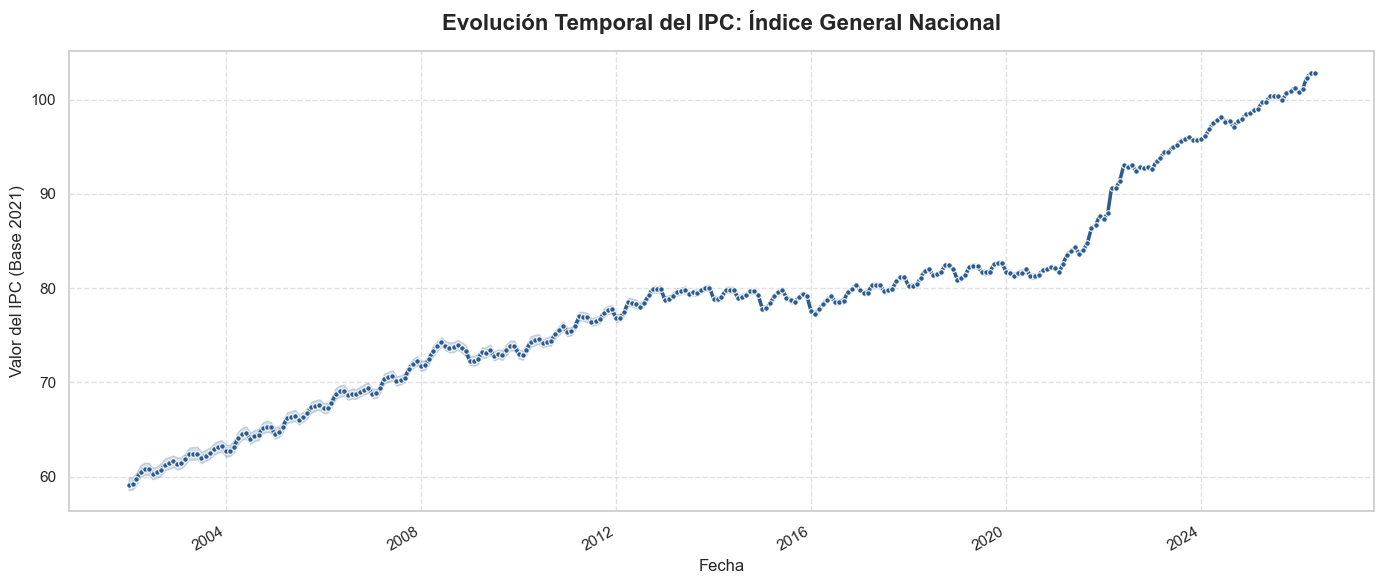

In [53]:
# 1. Combinar el DataFrame de IPC con las dimensiones de tiempo, sector y tipo de medida

df_ipc_completo = df_ipc.merge(df_tiempo, on='id_tiempo', how='inner') \
.merge(df_sectores_ipc, on='id_sector', how='inner') \
.merge(df_tipo_medida, on='id_medida', how='inner')
 
# Nota: Si tu tabla 'ipc.csv' ya incluye directamente los nombres de territorio 

# o códigos, asegúrate de filtrar por el agregado Nacional.

# Si tienes una columna 'id_territorio', añade: .merge(df_territorio, on='id_territorio', how='inner')
 
# 2. Filtrar para obtener ÚNICAMENTE el Índice General a nivel Nacional

# Ajusta los nombres exactos ('Índice', 'General', 'España' o 'Total Nacional') según tus datos reales

df_filtrado = df_ipc_completo[

    (df_ipc_completo['nombre_sector'].str.contains('General', case=False, na=False)) & 

    (df_ipc_completo['nombre_medida'].str.contains('Índice', case=False, na=False))

]
 
# 3. Convertir el periodo a formato datetime para que el eje X se ordene y dibuje correctamente

# Asumiendo que 'id_tiempo' tiene formato YYYYMM (ej. 202505) o que tienes una columna 'fecha'

if 'fecha' in df_filtrado.columns:

    df_filtrado['fecha_dt'] = pd.to_datetime(df_filtrado['fecha'])

else:

    df_filtrado['fecha_dt'] = pd.to_datetime(df_filtrado['id_tiempo'].astype(str) + '01', format='%Y%m%d')
 
# 4. Ordenar cronológicamente

df_filtrado = df_filtrado.sort_values('fecha_dt')
 
# 5. Construcción del Gráfico

plt.figure(figsize=(14, 6))

sns.lineplot(

    data=df_filtrado, 

    x='fecha_dt', 

    y='valor_ipc', 

    linewidth=2.5, 

    color='#2b5c8f', 

    marker='o', 

    markersize=4

)
 
# Personalización estética limpia

plt.title('Evolución Temporal del IPC: Índice General Nacional', fontsize=16, fontweight='bold', pad=15)

plt.xlabel('Fecha', fontsize=12)

plt.ylabel('Valor del IPC (Base 2021)', fontsize=12) # Ajusta la base según corresponda a tu dataset del INE

plt.grid(True, linestyle='--', alpha=0.6)
 
# Ajustar formato de fechas en el eje X para que no se amontone

plt.gcf().autofmt_xdate()
 
plt.tight_layout()

plt.show()
 